# Visualize prepared anomaly pairs

Loads the split datasets from `inst_data_prepare_simple.py` (`normal/` and `anomaly/`) and plots pairs inline.

Layout per pair: **normal prefix (gray) | context (blue) | future (green=normal, red=anomaly)**. NaN-padded steps appear as gaps.

In [1]:
import pickle, os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

NORMAL_SIGNAL_LENGTH = 256

# ---- config ----
DATA_ROOT = "./prepared_data_simple"
SPLIT     = "train"   # "train" or "val"
N_EACH    = 3         # examples from each case
VARIATE   = 0         # which variate to plot
SEED      = 0

NORMAL_PATH  = os.path.join(DATA_ROOT, "normal",  f"{SPLIT}_pairs.pkl")
ANOMALY_PATH = os.path.join(DATA_ROOT, "anomaly", f"{SPLIT}_pairs.pkl")

In [2]:
def load_pairs(path):
    with open(path, "rb") as f:
        return pickle.load(f)

normal_pairs  = load_pairs(NORMAL_PATH)
anomaly_pairs = load_pairs(ANOMALY_PATH)
print(f"normal-future  : {len(normal_pairs):>8} pairs  ({NORMAL_PATH})")
print(f"anomaly-future : {len(anomaly_pairs):>8} pairs  ({ANOMALY_PATH})")

normal-future  :   206711 pairs  (./prepared_data_simple/normal/train_pairs.pkl)
anomaly-future :    29523 pairs  (./prepared_data_simple/anomaly/train_pairs.pkl)


In [4]:
def plot_pair(ax, pair, variate=0):
    ctx = pair["context"]["target"]
    fut = pair["future"]["target"]
    normal = pair.get("normal_signal")
    F = ctx.shape[0]
    v = min(variate, F - 1)
    if normal is None:
        normal = np.full((F, NORMAL_SIGNAL_LENGTH), np.nan, dtype=np.float32)

    n_len, c_len, f_len = normal.shape[1], ctx.shape[1], fut.shape[1]
    series = np.concatenate([normal[v], ctx[v], fut[v]])
    x = np.arange(series.shape[0])

    n_end, c_end, f_end = n_len, n_len + c_len, n_len + c_len + f_len
    fut_color = "tab:red" if pair.get("type") == "anomaly" else "tab:green"

    ax.axvspan(0, n_end, color="gray", alpha=0.12, label="normal prefix")
    ax.axvspan(n_end, c_end, color="tab:blue", alpha=0.10, label="context")
    ax.axvspan(c_end, f_end, color=fut_color, alpha=0.18, label="future")

    ax.plot(x[:n_end], series[:n_end], color="gray", lw=0.8)
    ax.plot(x[n_end:c_end], series[n_end:c_end], color="tab:blue", lw=0.9)
    ax.plot(x[c_end:f_end], series[c_end:f_end], color=fut_color, lw=1.2)

    ax.axvline(n_end, color="k", ls=":", lw=0.6)
    ax.axvline(c_end, color="k", ls="--", lw=0.8)

    n_pad = int(np.isnan(fut[v]).sum())
    ax.set_title(f"future={pair.get('type')}  (variate {v}, future pad={n_pad})", fontsize=9)
    ax.tick_params(labelsize=7)

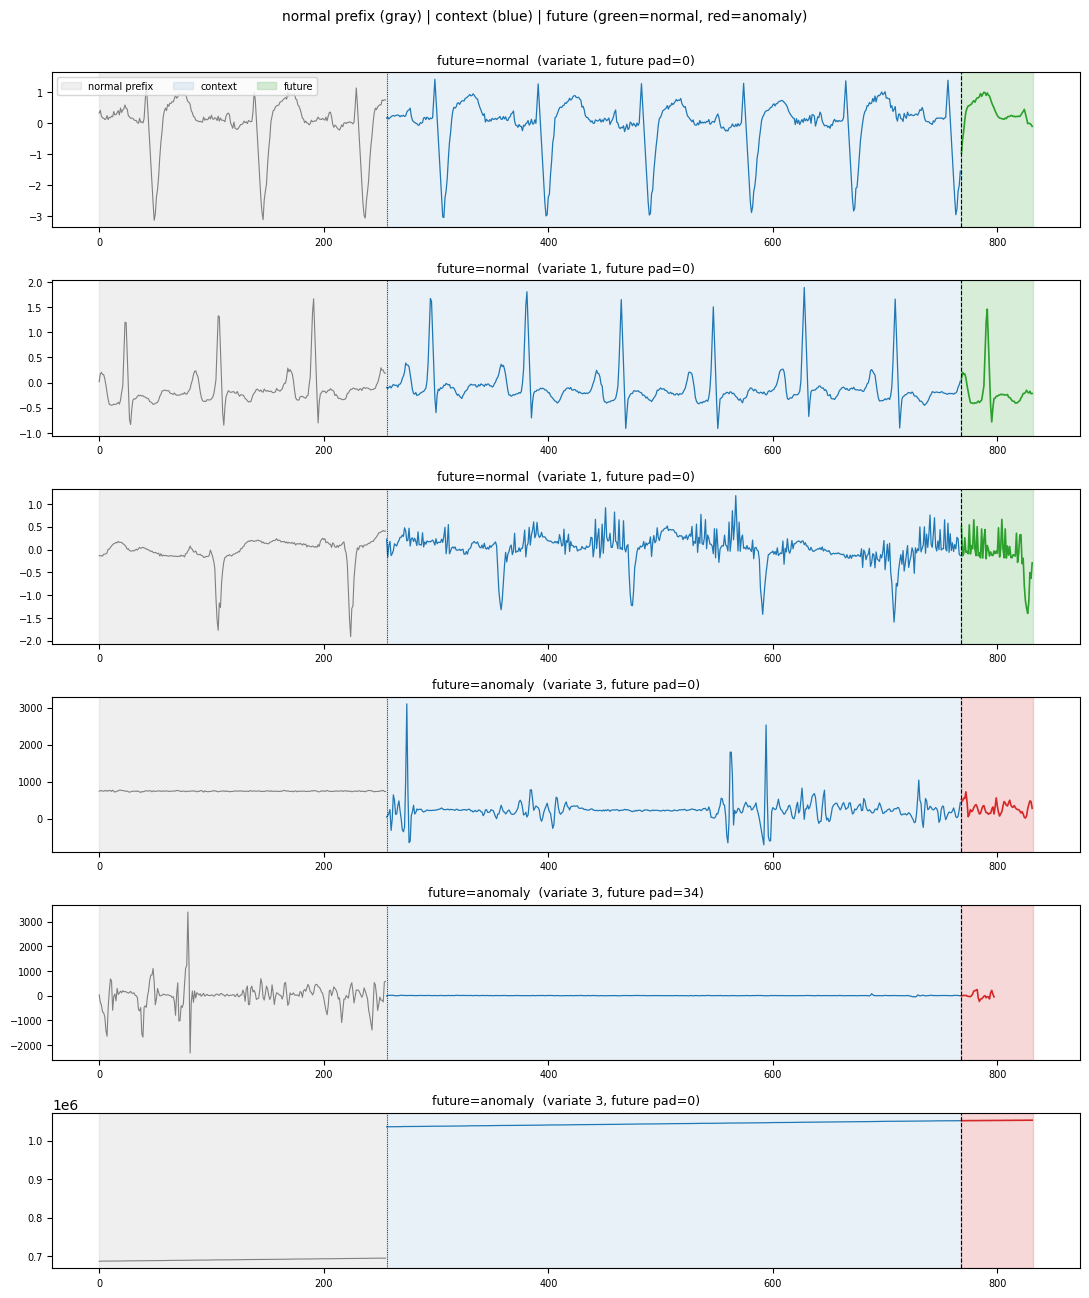

In [5]:
rng = np.random.default_rng(SEED)

def sample(pair_list, k):
    if not pair_list:
        return []
    k = min(k, len(pair_list))
    return [pair_list[i] for i in rng.choice(len(pair_list), size=k, replace=False)]

chosen = sample(normal_pairs, N_EACH) + sample(anomaly_pairs, N_EACH)

n = len(chosen)
fig, axes = plt.subplots(n, 1, figsize=(11, 2.2 * n), squeeze=False)
for ax, p in zip(axes[:, 0], chosen):
    plot_pair(ax, p, 3)
axes[0, 0].legend(loc="upper left", fontsize=7, ncol=3)
fig.suptitle("normal prefix (gray) | context (blue) | future (green=normal, red=anomaly)", fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

type        : anomaly
context     : (2, 512)
future      : (2, 64)
normal_signal: (2, 256)
future NaN pad (variate 0): 62


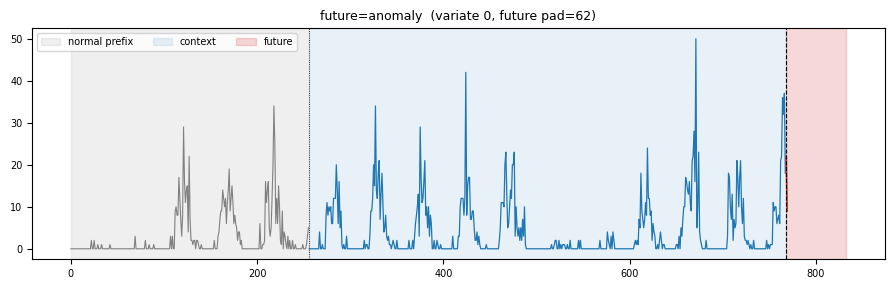

In [6]:
# Inspect a single pair
case_pairs = anomaly_pairs if anomaly_pairs else normal_pairs
idx = 0
p = case_pairs[idx]
print("type        :", p.get("type"))
print("context     :", p["context"]["target"].shape)
print("future      :", p["future"]["target"].shape)
ns = p.get("normal_signal")
print("normal_signal:", None if ns is None else ns.shape)
print("future NaN pad (variate 0):", int(np.isnan(p["future"]["target"][0]).sum()))

fig, ax = plt.subplots(figsize=(11, 3))
plot_pair(ax, p, VARIATE)
ax.legend(loc="upper left", fontsize=7, ncol=3)
plt.show()